In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [2]:
credit_card = pd.read_csv("creditcard.csv")


In [3]:
credit_card.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
credit_card[["Time","Amount","Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


## TIME FEATURES AND SOME FEATURE ENGINEERING

time feature are in seconds we will transform into minutes and hours for better understanding

In [5]:
timedelta = pd.to_timedelta(credit_card['Time'],unit = 's')
credit_card['Time_min'] = (timedelta.dt.components.minutes).astype(int)
credit_card['Time_hour'] = (timedelta.dt.components.minutes).astype(int)

In [6]:
import warnings
warnings.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_876\2308714057.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(credit_card[credit_card['Class']==0]["Time_hour"],color= 'g')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_876\2308714057.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(credit_card[

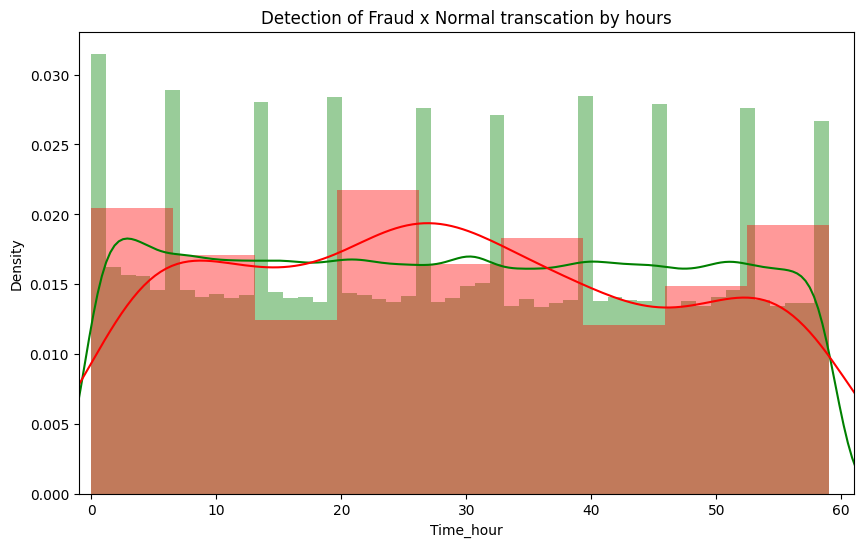

In [7]:
plt.figure(figsize=(10,6))
sns.distplot(credit_card[credit_card['Class']==0]["Time_hour"],color= 'g')
sns.distplot(credit_card[credit_card['Class']==1]["Time_hour"],color= 'r')

plt.title("Detection of Fraud x Normal transcation by hours", fontsize=12 )
plt.xlim([-1,61])
plt.show()

## STATISTICS OF AMOUNT CLASS FRAUD AND NORMAL TRANSCATION

In [8]:
fraud = credit_card[credit_card['Class'] == 1]
normal_transcation = credit_card[credit_card['Class'] == 0]

In [9]:
print("Fraud Transcation statistics")
print(fraud["Amount"].describe())

Fraud Transcation statistics
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [10]:
print("NormalTranscation statistics")
print(normal_transcation["Amount"].describe())

NormalTranscation statistics
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [11]:
credit_card['Amount_log'] = np.log(credit_card.Amount+0.01)

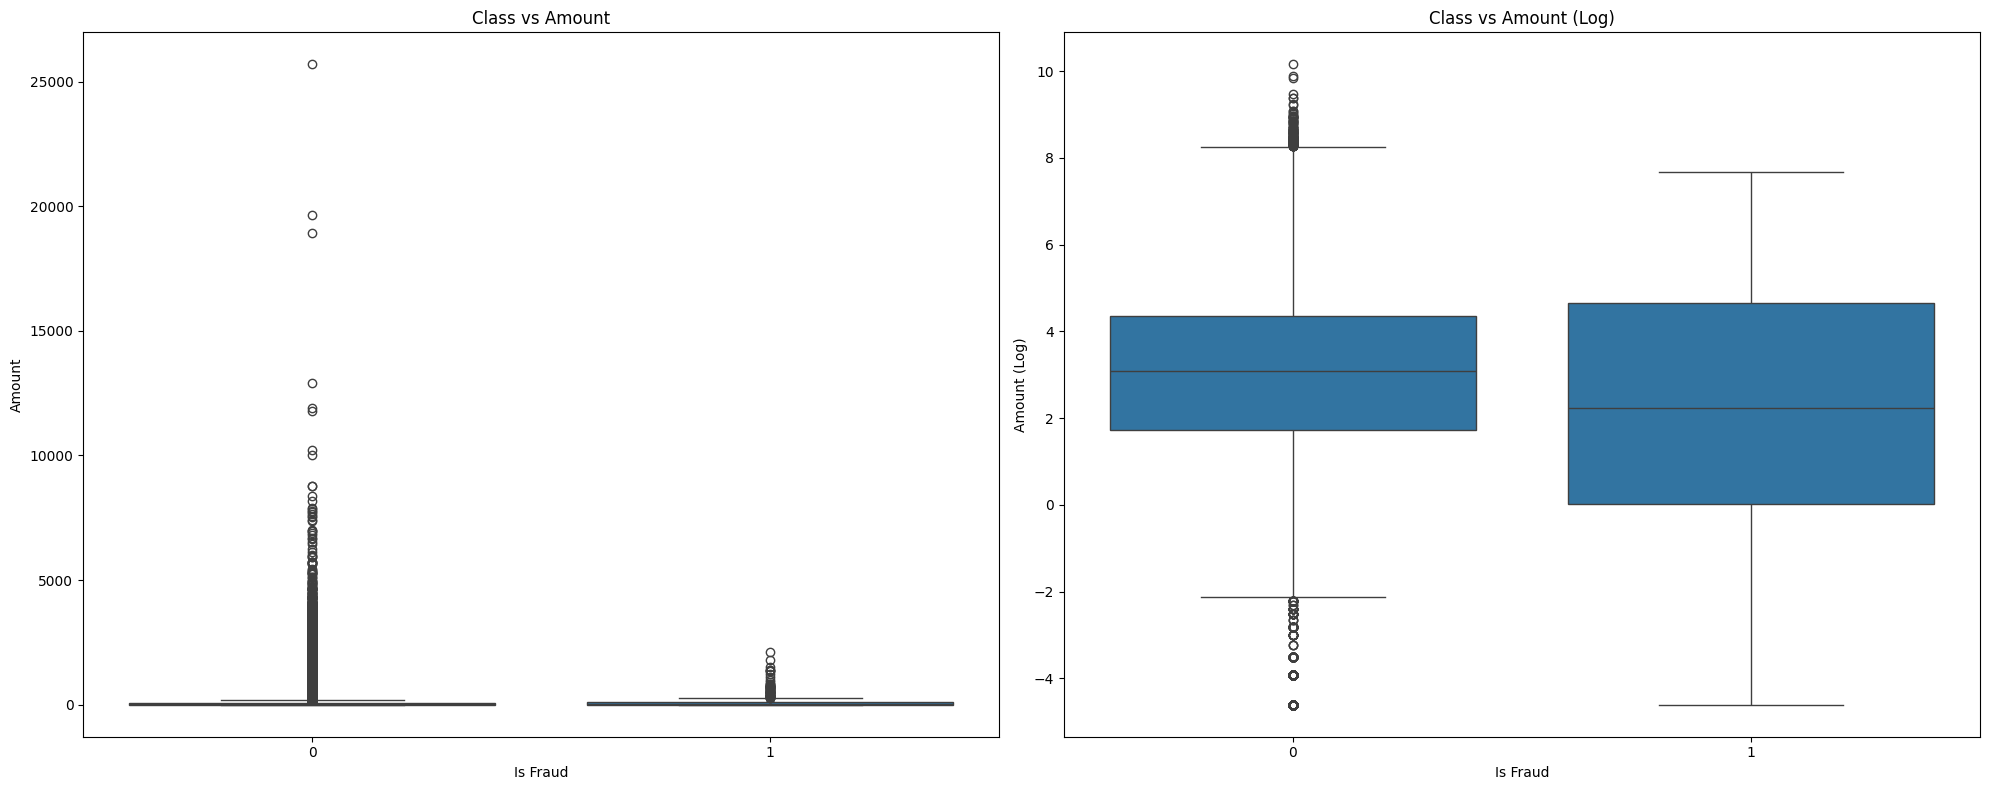

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
ax = sns.boxplot(x="Class", y="Amount", data=credit_card)
ax.set_title("Class vs Amount", fontsize=12)
ax.set_xlabel("Is Fraud")
ax.set_ylabel("Amount")

plt.subplot(1, 2, 2)
ax1 = sns.boxplot(x="Class", y="Amount_log", data=credit_card)
ax1.set_title("Class vs Amount (Log)", fontsize=12)
ax1.set_xlabel("Is Fraud")
ax1.set_ylabel("Amount (Log)")

plt.tight_layout()
plt.show()

## Looking the scatterplot for time_min distribution by Amount

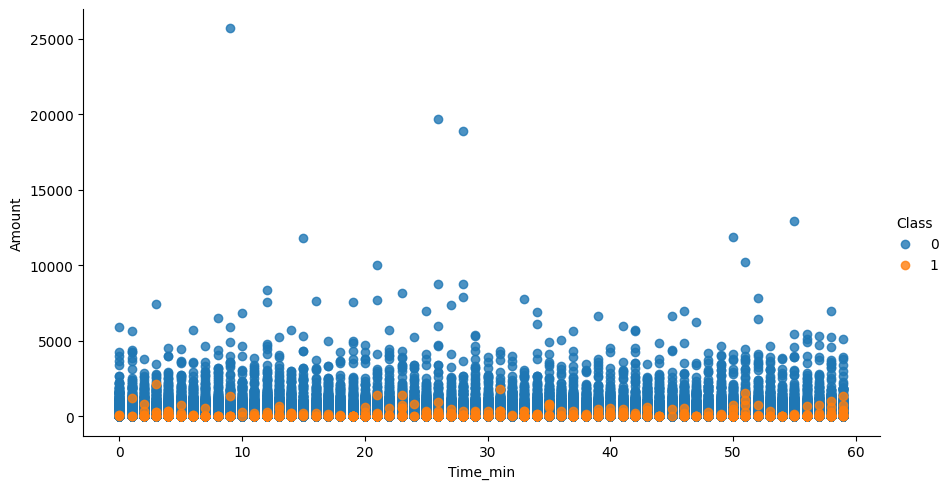

In [13]:
ax = sns.lmplot(y="Amount",x="Time_min",fit_reg = False,aspect=1.8, data = credit_card,hue = 'Class')
plt.show()

## Looking the scatterplot for time_min distribution by Amount

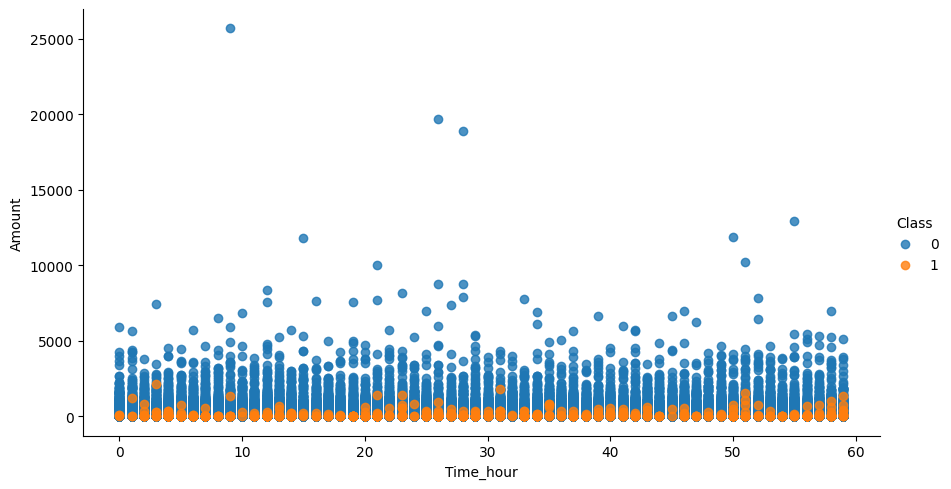

In [14]:
ax = sns.lmplot(y="Amount",x="Time_hour",fit_reg = False,aspect=1.8, data = credit_card,hue = 'Class')
plt.show()

## BOXPLOT to search different distributions

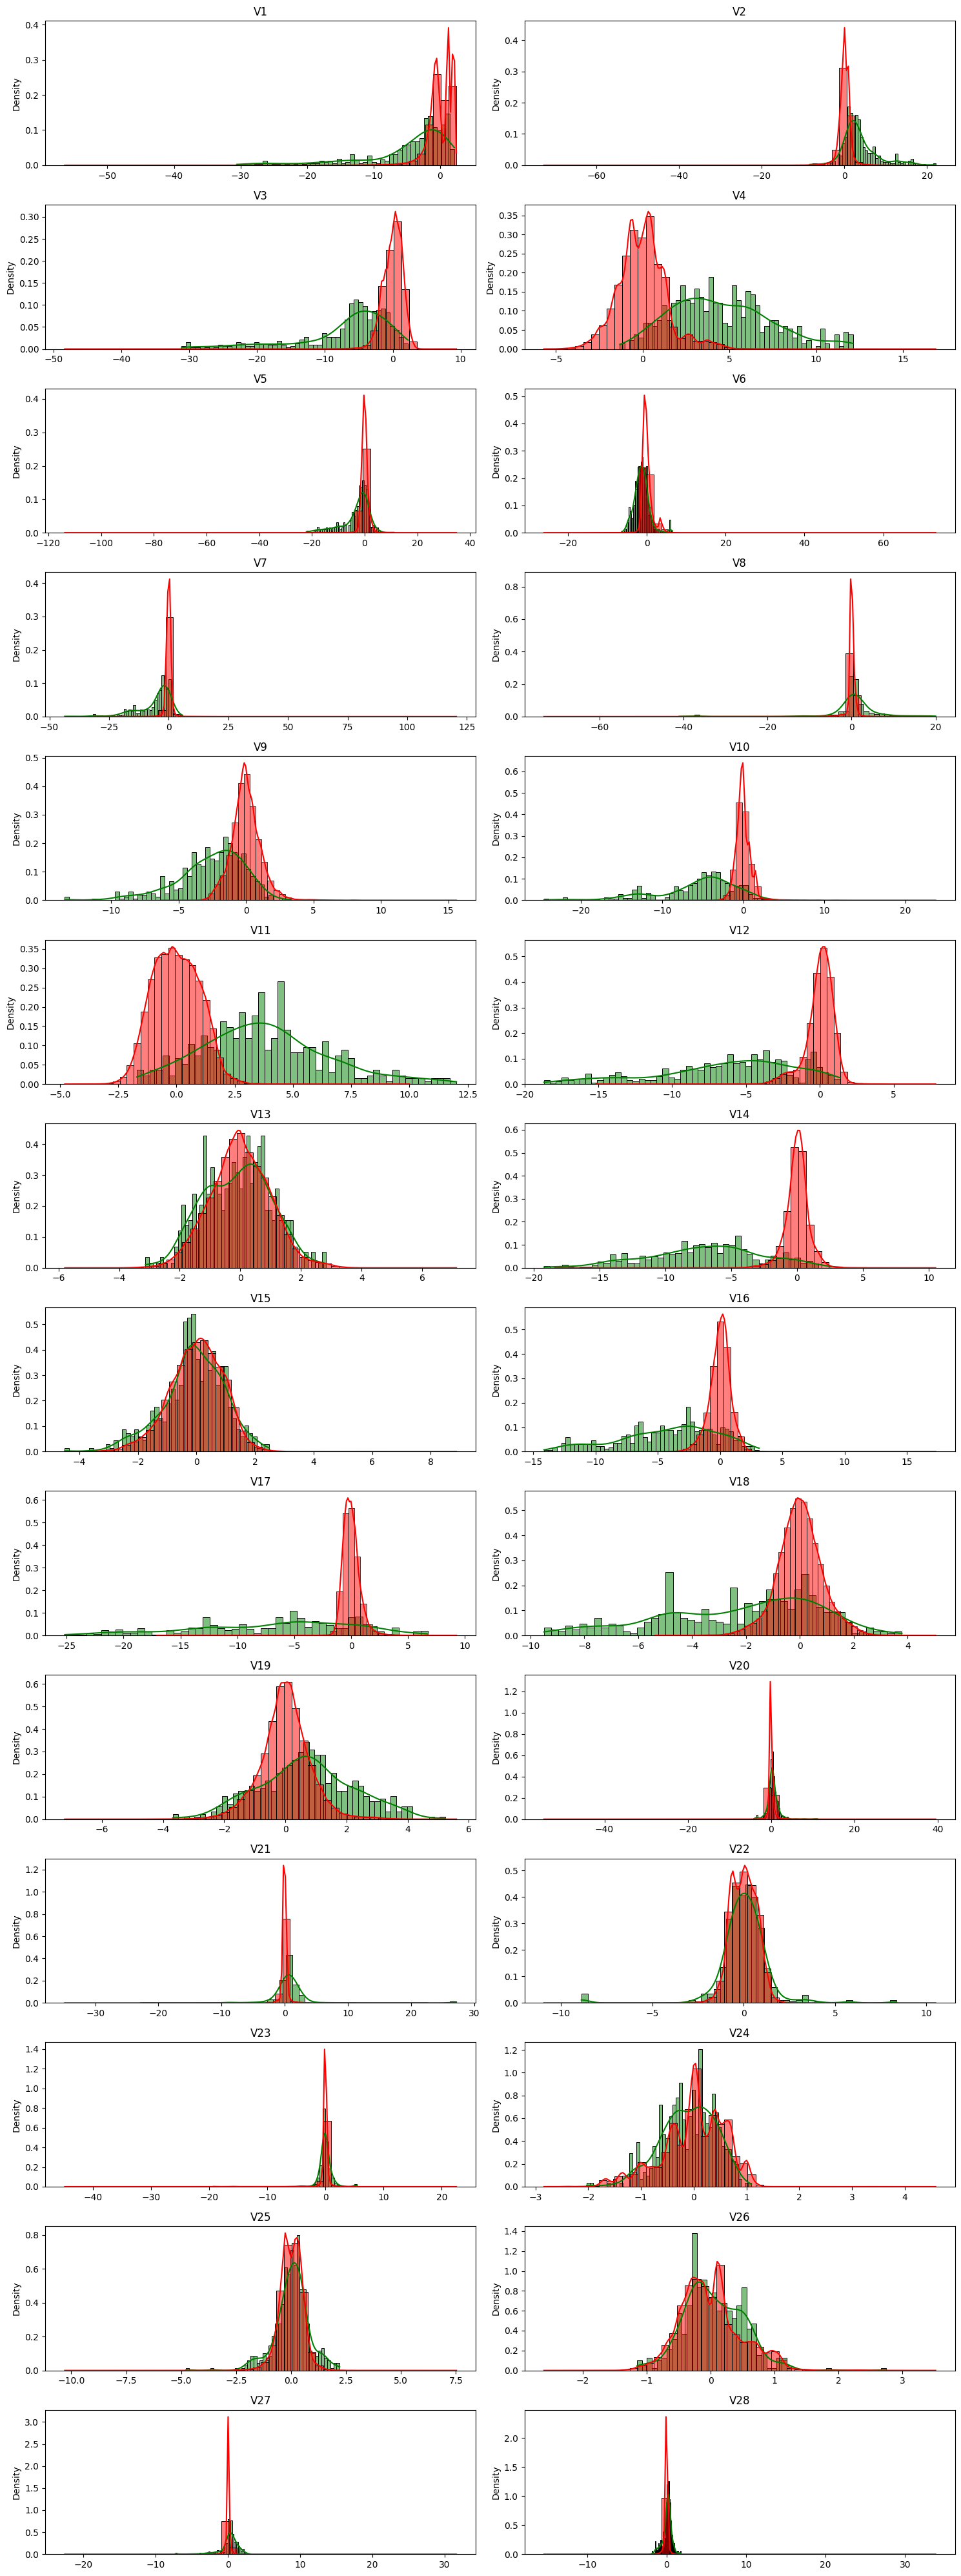

In [15]:
columns = credit_card.iloc[:, 1:29].columns

frauds = credit_card["Class"] == 1
normal = credit_card["Class"] == 0

grid = gridspec.GridSpec(14, 2)

plt.figure(figsize=(15, 40))

for n, col in enumerate(columns):
    ax = plt.subplot(grid[n])

    sns.histplot(credit_card.loc[frauds, col],
                 bins=50, color='green',
                 stat='density', kde=True)

    sns.histplot(credit_card.loc[normal, col],
                 bins=50, color='red',
                 stat='density', kde=True)

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

## FEATURE ENGINEERING

In [16]:
credit_card.columns


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Time_min', 'Time_hour', 'Amount_log'],
      dtype='object')

In [17]:
credit_card  = credit_card[['Time_min', 'Time_hour' ,'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10','V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount','Amount_log',
       'Class']]

In [18]:
credit_card.Amount = np.log(credit_card.Amount+0.001)

In [19]:
credit_card.head()

,Time_min,Time_hour,Time,V1,V2,V3,V4,V5,V6,V7,...,V22,V23,V24,V25,V26,V27,V28,Amount,Amount_log,Class
0,0,0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.008105,5.008166,0
1,0,0,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.989913,0.993252,0
2,0,0,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.936641,5.936665,0
3,0,0,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.816249,4.816322,0
4,0,0,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.248367,4.248495,0


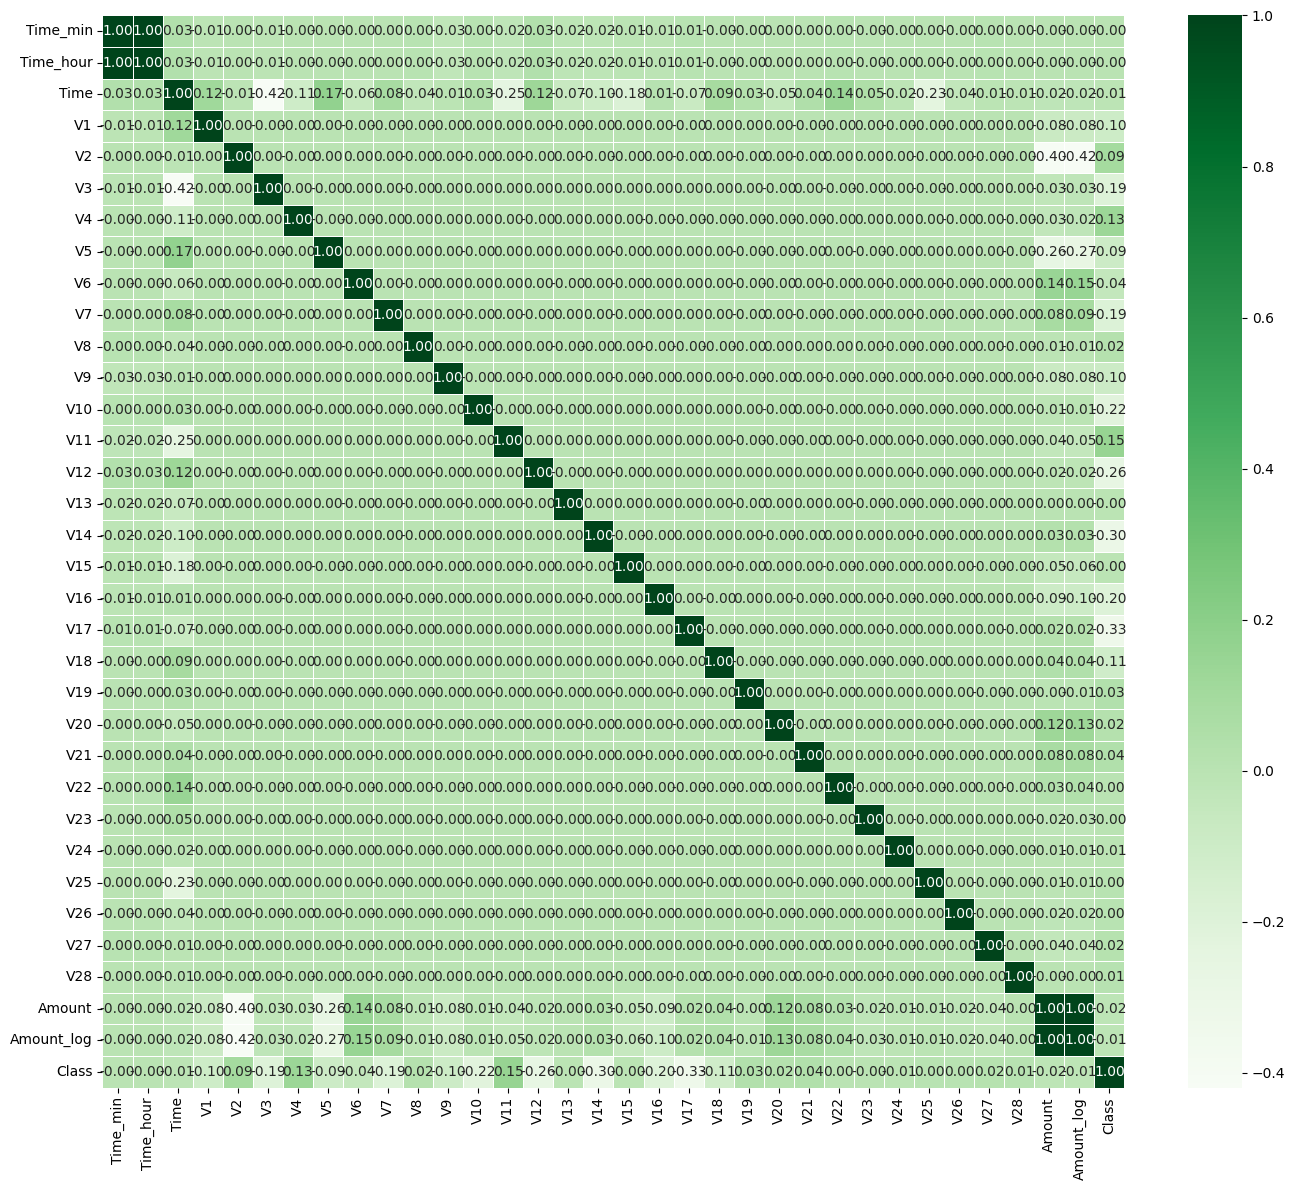

In [20]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    credit_card.corr(),
    cmap="Greens",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.tight_layout()
plt.show()

## PREPROCESSING


pip install imblearn

In [21]:
from imblearn.pipeline import make_pipeline as make_pipeline_imb
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import make_pipeline
from imblearn.metrics import classification_report_imbalanced

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
from collections import Counter

from sklearn.metrics import (
    precision_score,
    confusion_matrix,
    recall_score,
    fbeta_score,
    precision_recall_curve,
    accuracy_score
)

In [22]:
X = credit_card.drop(["Class"],axis = 1).values

Y = credit_card["Class"].values

In [23]:
def print_results(headline,true_value,pred):
    print(headline)
    print("Accuracy: {}".format(accuracy_score(true_value,pred)))
    print("Precision: {}".format(precision_score(true_value,pred)))
    print("Recall: {}".format(recall_score(true_value,pred)))
    print("f2:{} ".format(fbeta_score(true_value,pred)))

    
X_train,X_test,Y_train,Y_test = train_test_split(
        X,Y,test_size=0.2,stratify = Y,random_state = 2
)

Classifier = RandomForestClassifier

smote_pipeline = make_pipeline_imb(SMOTE(random_state=4),\
                                   Classifier(random_state =42))

smote_model = smote_pipeline.fit(X_train,Y_train)
smote_predidciton = smote_model.predict(X_test)

print("normal data distrobution:{}",format(Counter(Y)))

normal data distrobution:{} Counter({np.int64(0): 284315, np.int64(1): 492})


In [24]:
X_smote,Y_smote = SMOTE().fit_resample(X,Y)
print("SMOTE data distribution : {}".format(Counter(Y_smote)))

SMOTE data distribution : Counter({np.int64(0): 284315, np.int64(1): 284315})


In [25]:
smote_prediction = smote_model.predict(X_test)

## EVUALATING THE MODEL SMOTE+ RANDOOM FOREST 

In [26]:
print("Confusion Matrix:")
print(confusion_matrix(Y_test, smote_prediction))

print("\nSMOTE Pipeline Score: {}".format(smote_model.score(X_test, Y_test)))

print_results("\nSMOTE + Random Forest Classification", Y_test, smote_prediction)

Confusion Matrix:
[[56851    13]
 [   14    84]]

SMOTE Pipeline Score: 0.9995259997893332

SMOTE + Random Forest Classification
Accuracy: 0.9995259997893332
Precision: 0.865979381443299
Recall: 0.8571428571428571


TypeError: missing a required argument: 'beta'

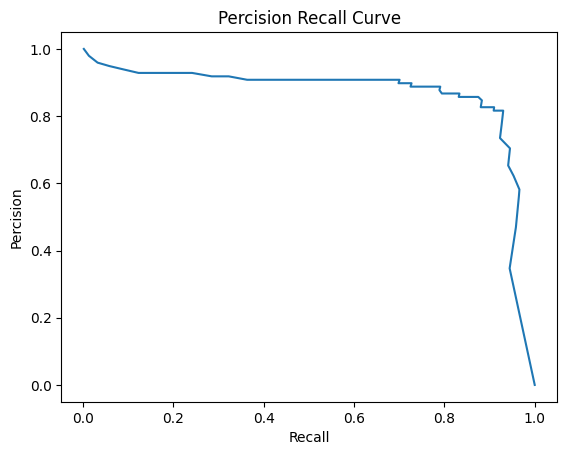

In [27]:
Y_pred_prob = smote_pipeline.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(Y_test,Y_pred_prob)

plt.plot(precision, recall)
plt.xlabel("Recall")
plt.ylabel("Percision")
plt.title("Percision Recall Curve")
plt.show()

# ROC CURVE IS OVERFITTED CURVE

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score,GridSearchCV

In [29]:
param_grid = {
    "max_depth":[3,5,None],
    "n_estimators":[3,5,10],
    "max_features":[5,6,7,8]
    

}

model = RandomForestClassifier(max_features =3,
                               max_depth=2,
                               n_estimators =10,
                               random_state =3,
                              criterion = 'entropy',
                               n_jobs=1,verbose=1)


In [30]:
grid_search = GridSearchCV(model,param_grid,cv = 5,scoring = 'recall') 
grid_search.fit(X_train,Y_train)

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.5s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.4s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.3s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.3s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    5.8s finished
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

,estimator,"RandomForestC...=3, verbose=1)"
,param_grid,"{'max_depth': [3, 5, ...], 'max_features': [5, 6, ...], 'n_estimators': [3, 5, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,10


In [31]:
print(grid_search.best_score_)
print(grid_search.best_params_)

0.7716001298279779
{'max_depth': None, 'max_features': 7, 'n_estimators': 10}


In [32]:
rf = RandomForestClassifier(max_depth=5,max_features=7,n_estimators=10)
rf.fit(X_train,Y_train)

print("Training score data:")
print(rf.score(X_train,Y_train))

Training score data:
0.9995040488051088


In [36]:
from sklearn.metrics import confusion_matrix

Y_pred = rf.predict(X_test)

print(confusion_matrix(Y_test, Y_pred))

print_results("RF Classification", Y_test, Y_pred, beta=1)

[[56854    10]
 [   22    76]]


TypeError: print_results() got an unexpected keyword argument 'beta'

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_876\3204892712.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=90)


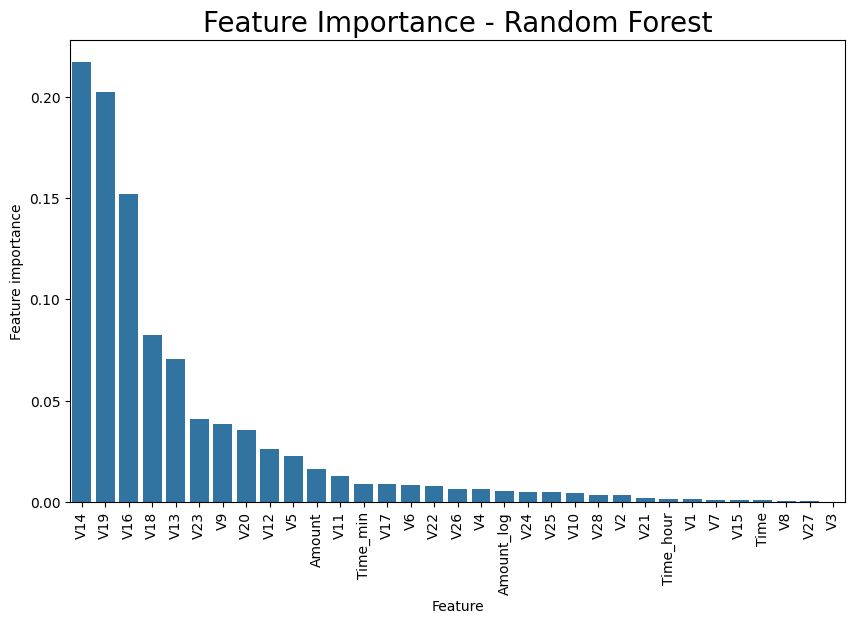

In [38]:
features = [
    'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7',
    'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14',
    'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26',
    'V27', 'V28', 'Amount',
    'Time_min', 'Time_hour', 'Amount_log'
]

plt.figure(figsize=(10,6))

feat_import = pd.DataFrame({
    "Feature": features,
    "Feature importance": rf.feature_importances_
})

feat_import = feat_import.sort_values(by='Feature importance', ascending=False)

g = sns.barplot(x='Feature', y='Feature importance', data=feat_import)

g.set_xticklabels(g.get_xticklabels(), rotation=90)

g.set_title('Feature Importance - Random Forest', fontsize=20)

plt.show()

## ROC CURVE - RANDOM FOREST

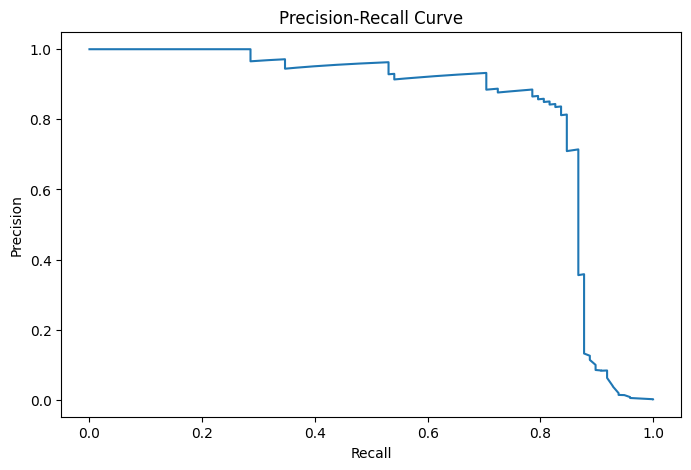

In [40]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Probability prediction
Y_pred_prob = rf.predict_proba(X_test)[:,1]

# Precision Recall values
precision, recall, thresholds = precision_recall_curve(
    Y_test,
    Y_pred_prob
)

# Plot
plt.figure(figsize=(8,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [41]:
results = cross_val_score(rf,X_train,Y_train,cv =10,scoring='recall')
results #It gives recall score for each of the 10 folds.

array([0.66666667, 0.8       , 0.75      , 0.85      , 0.625     ,
       0.56410256, 0.69230769, 0.79487179, 0.69230769, 0.84615385])

##  MOEDELLING LOGISTIC REGRESSION WITH HYPER PARAMETERS

In [42]:
param_grid = {
    'C':[0.01,0.1,1,10],
    'penalty':['l1','l2']
}
logreg = LogisticRegression(solver = 'liblinear',random_state = 2)
grid_search_lr = GridSearchCV(logreg,
                              param_grid = param_grid,
                              scoring = 'recall',
                              cv = 5,
                             n_jobs = -1)

## SETTING THE BEST PERFORAMNCE AS PARAMETERW OF OUR MODEL

In [48]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logreg,
    X_train,
    Y_train,
    cv=10,
    scoring='recall'
)

print(cv_scores)
print("Mean Recall:", cv_scores.mean())

[0.58974359 0.625      0.55       0.675      0.375      0.35897436
 0.51282051 0.58974359 0.71794872 0.69230769]
Mean Recall: 0.5686538461538462


# PRECISION RECALL CURVE OF LR

[8.33745440e-06 2.36374260e-05 2.99598843e-05 9.66372416e-04
 1.36382665e-03]


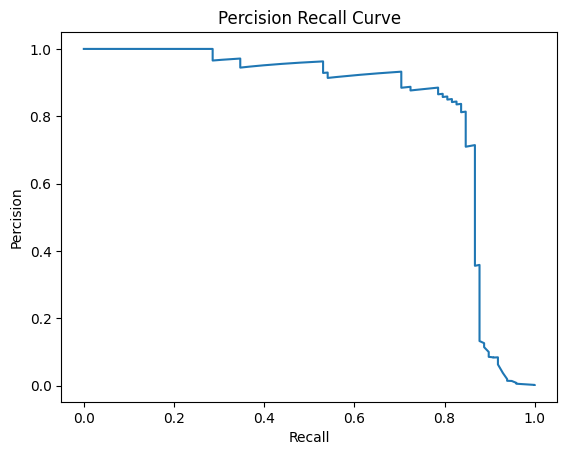

In [52]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    random_state=2
)

# Train
logreg.fit(X_train, Y_train)

# Probability prediction
Y_pred_prob = logreg.predict_proba(X_test)[:,1]

print(Y_pred_prob[:5])

plt.plot(recall,precision)

plt.xlabel('Recall')
plt.ylabel('Percision')
plt.title('Percision Recall Curve')
plt.show()